## Miguel Antunes Vilela
### 2G11, 10769607

In [94]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as st
import math as mt

### Questão 1
A) Média, mediana.

In [11]:
X = [64, 70, 76, 63, 78, 69, 69, 65, 75, 73, 67, 77, 48, 94]

In [12]:
meanX = np.mean(X)
sortedX = np.sort(X)
medianX = np.median(X)

print(f"Média: {round(meanX, 2)}")
print(f"Mediana: {round(medianX, 2)}")

Média: 70.57
Mediana: 69.5


B) Moda, máximo, mínimo e amplitude da base de dados.

In [13]:
modeX = st.mode(X)
maxX = max(X)
minX = min(X)
scope = maxX - minX

print(f"""
Moda = {modeX}
Máximo = {maxX}
Mínimo = {minX}
Amplitude = {scope}
""")


Moda = 69
Máximo = 94
Mínimo = 48
Amplitude = 46



C) Variância, desvio padrão, quartis, e amplitude entre quartis (AIQ).

In [14]:
stdX = np.std(X)
variance = stdX**2
q1X = mt.floor(np.percentile(sortedX, 25))
q3X = mt.ceil(np.percentile(sortedX, 75))
aiqX = q3X - q1X

print(f"""
Variância = {round(variance, 2)}
Desvio Padrão = {round(stdX, 2)}
Cinco números (limites dos quartis): {minX} --- {q1X} --- {medianX} --- {q3X} --- {maxX}
Amplitude entre quartis: {aiqX}
""")


Variância = 97.1
Desvio Padrão = 9.85
Cinco números (limites dos quartis): 48 --- 65 --- 69.5 --- 76 --- 94
Amplitude entre quartis: 11



D) Verifique se a base de dados acima tem outliers. Use a regra 1.5 · AIQ

In [15]:
upperLimit = q3X + (aiqX*1.5)
lowerLimit = q1X - (aiqX*1.5)
filteredX = sortedX
outliers = []

for i in range(len(filteredX)-1):
    if filteredX[i] > upperLimit or filteredX[i] < lowerLimit:
        outliers.append(int(filteredX[i]))
        filteredX = np.delete(filteredX, i)

print(f"""
Os outliers nessa lista são: {outliers}
Os items restantes são: {filteredX}
""")


Os outliers nessa lista são: [48, 94]
Os items restantes são: [63 64 65 67 69 69 70 73 75 76 77 78]



E) Esboçe o histograma da base de dados acima.

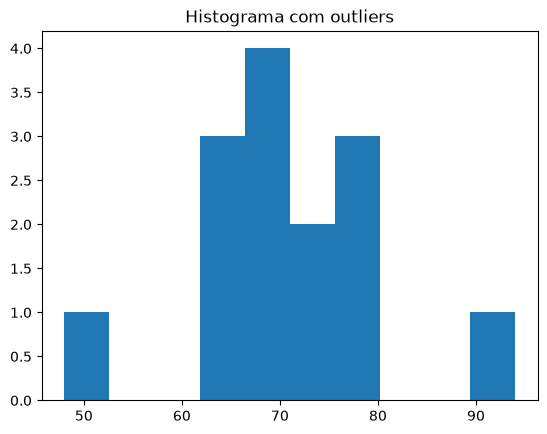

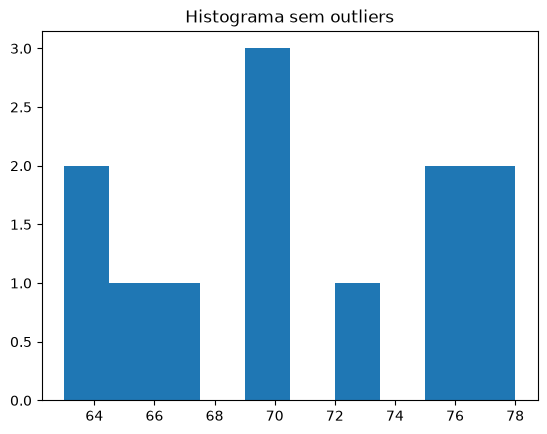

In [16]:
plt.title("Histograma com outliers")
plt.hist(sortedX, bins=10)
plt.show()

plt.title("Histograma sem outliers")
plt.hist(filteredX, bins=10)
plt.show()

F) Esboçe o boxplot da base de dados acima. Se existirem outliers, represente a linha de limiar inferior
e/ou superior.

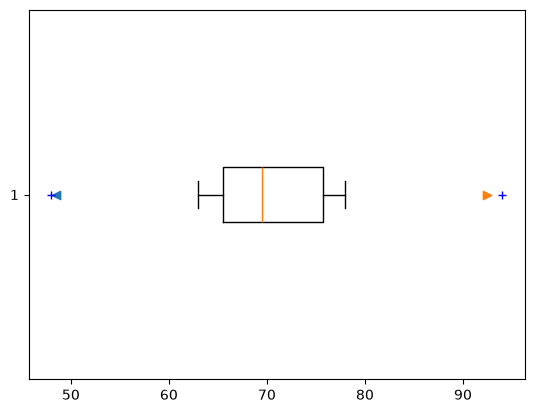

In [17]:
plt.boxplot(sortedX, orientation="horizontal", sym="b+")
plt.scatter(lowerLimit, 1, marker = '<')
plt.scatter(upperLimit, 1, marker = '>')
plt.show()

### Questão 2

In [ ]:
df = pd.read_csv('/workspaces/Analise-Dados/Labs/Players.csv', engine='python')
df = df.dropna()
num = 0
for coluna in df:
    print(f"Coluna {num}: {coluna}")
    num += 1

Coluna 0: Unnamed: 0
Coluna 1: Player
Coluna 2: height
Coluna 3: weight
Coluna 4: collage
Coluna 5: born
Coluna 6: birth_city
Coluna 7: birth_state


A) Média, mediana.

In [89]:
medias = []
medians = []
for coluna in df.select_dtypes(include=[np.number]):
    if coluna != 'Unnamed: 0':
        print(f"Média {coluna}: {df[coluna].mean()}")
        medias.append(df[coluna].mean())
        dfSorted = df.sort_values(by=coluna)
        print(f"Mediana {coluna}: {dfSorted[coluna].median()}\n")
        medians.append(df[coluna].median())

Média height: 198.66353088742554
Mediana height: 198.0

Média weight: 94.72342427093133
Mediana weight: 95.0

Média born: 1964.0636563185951
Mediana born: 1965.0



B) Moda, máximo, mínimo e amplitude da base de dados.

In [73]:
for coluna in df.select_dtypes(include=[np.number]):
    if coluna != 'Unnamed: 0':
        print(f"Moda em {coluna}: {df[coluna].mode()}")
        print(f"Máximo em {coluna}: {df[coluna].max()}")
        print(f"Mínimo em {coluna}: {df[coluna].min()}")
        print(f"Amplitude em {coluna}: {df[coluna].max() - df[coluna].min()}\n\n")

Moda em height: 0    201.0
Name: height, dtype: float64
Máximo em height: 231.0
Mínimo em height: 160.0
Amplitude em height: 71.0


Moda em weight: 0    86.0
Name: weight, dtype: float64
Máximo em weight: 163.0
Mínimo em weight: 60.0
Amplitude em weight: 103.0


Moda em born: 0    1970.0
Name: born, dtype: float64
Máximo em born: 1997.0
Mínimo em born: 1915.0
Amplitude em born: 82.0




C) Variância, desvio padrão, quartis, e amplitude entre quartis (AIQ).

In [98]:
q1s = []
q3s = []
for coluna in df.select_dtypes(include=[np.number]):
    if coluna != 'Unnamed: 0':
        print(f"Variânça em {coluna}: {round(df[coluna].std()**2, 2)}")
        print(f"Desvio Padrão em {coluna}: {round(df[coluna].std(), 2)}")
        dfSorted = df.sort_values(by=coluna)
        q1s.append(mt.floor(np.percentile(dfSorted[coluna], 25)))
        q3s.append(mt.ceil(np.percentile(dfSorted[coluna], 75)))
        print(f"5 Pontos quartis: {df[coluna].min()} --- {mt.floor(np.percentile(dfSorted[coluna], 25))} --- {dfSorted[coluna].median()} --- {mt.ceil(np.percentile(dfSorted[coluna], 75))} --- {df[coluna].max()}")
        print(f"AIQ: {mt.ceil(np.percentile(dfSorted[coluna], 75)) - mt.floor(np.percentile(dfSorted[coluna], 25))}\n\n")
        

Variânça em height: 81.78
Desvio Padrão em height: 9.04
5 Pontos quartis: 160.0 --- 193 --- 198.0 --- 206 --- 231.0
AIQ: 13


Variânça em weight: 139.36
Desvio Padrão em weight: 11.8
5 Pontos quartis: 60.0 --- 86 --- 95.0 --- 102 --- 163.0
AIQ: 16


Variânça em born: 346.11
Desvio Padrão em born: 18.6
5 Pontos quartis: 1915.0 --- 1952 --- 1965.0 --- 1979 --- 1997.0
AIQ: 27




D) Verifique se a base de dados acima tem outliers. Use a regra 1.5 · AIQ

In [105]:
i = 0
lowerLimits = []
upperLimits = []
for coluna in df.select_dtypes(include=[np.number]):
    if coluna != 'Unnamed: 0':
        lowerLimits.append(q1s[i] - (q3s[i] - q1s[i])*1.5)
        upperLimits.append(q3s[i] + (q3s[i] - q1s[i])*1.5)
        outliers = []
        for j in df[coluna]:
            if j > upperLimits[i] or j < lowerLimits[i]:
                outliers.append(j)
        print(f"Os outliers em {coluna} são: {outliers}")

        i+=1

Os outliers em height são: [173.0, 170.0, 173.0, 226.0, 231.0, 168.0, 160.0, 170.0, 170.0, 229.0, 165.0, 226.0]
Os outliers em weight são: [127.0, 60.0, 61.0, 129.0, 127.0, 147.0, 149.0, 127.0, 147.0, 129.0, 127.0, 61.0, 136.0, 128.0, 131.0, 127.0, 142.0, 127.0, 127.0, 131.0, 131.0, 127.0, 139.0, 138.0, 163.0]
Os outliers em born são: []


E) Esboçe o histograma da base de dados acima.

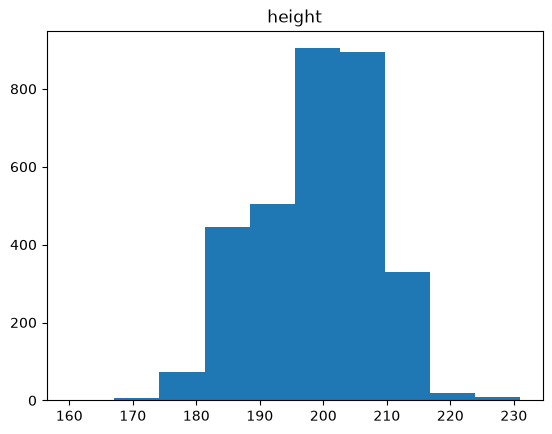

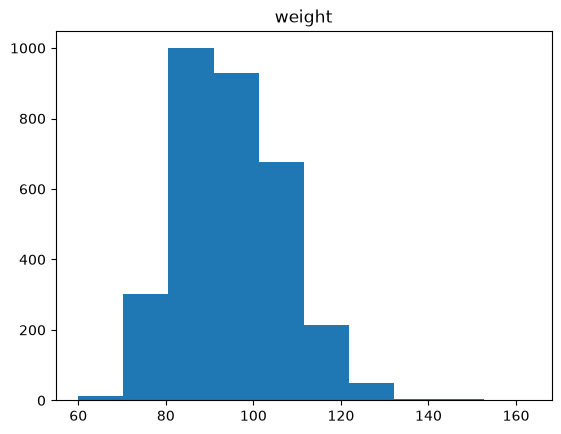

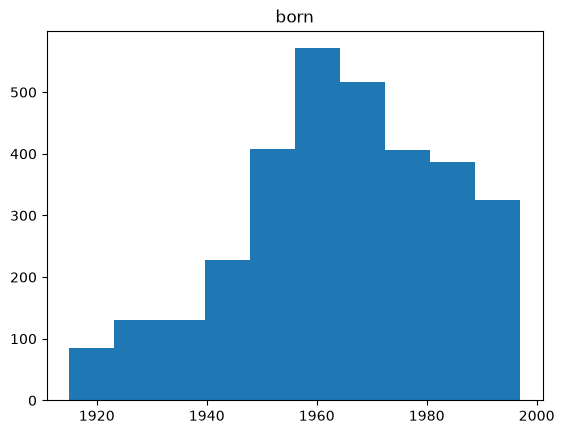

In [109]:
for coluna in df.select_dtypes(include=[np.number]):
    if coluna != 'Unnamed: 0':
        plt.title(coluna)
        plt.hist(df[coluna], bins=10)
        plt.show()

F) Esboçe o boxplot da base de dados acima. Se existirem outliers, represente a linha de limiar inferior
e/ou superior.

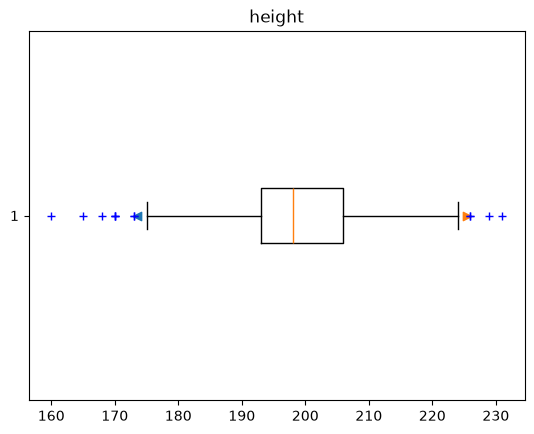

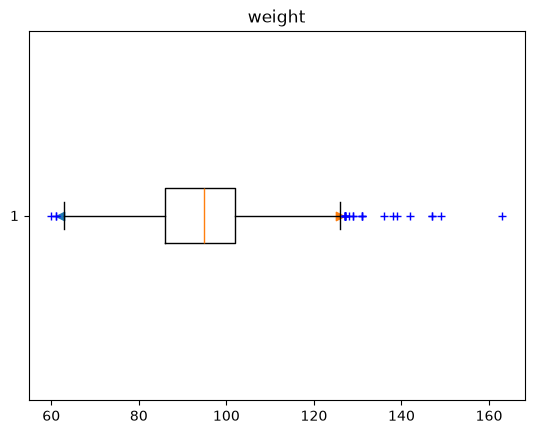

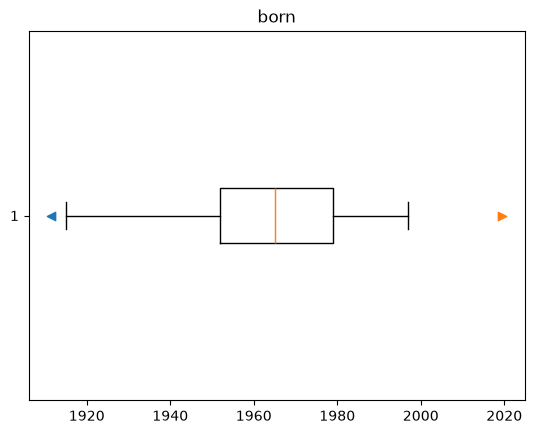

In [117]:
i = 0
for coluna in df.select_dtypes(include=[np.number]):
    if coluna != 'Unnamed: 0':
        plt.boxplot(df[coluna], orientation="horizontal", sym="b+")
        plt.scatter(lowerLimits[i], 1, marker = '<')
        plt.scatter(upperLimits[i], 1, marker = '>')
        plt.title(coluna)
        i += 1
        plt.show()